In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:

# Excel file path
excel_file = 'customer_churn_data_raw.xlsx'

# Create SQLite database connection
conn = sqlite3.connect('customer_churn.db')

# Read all sheet names from Excel file
excel_data = pd.ExcelFile(excel_file)

for sheet in excel_data.sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet) # Read sheet into dataframe
    # Write dataframe to SQLite table
    df.to_sql(
        name=sheet,
        con=conn,
        if_exists='replace',
        index=False
    )

conn.close()

print("All sheets successfully converted into SQLite tables.")

All sheets successfully converted into SQLite tables.


In [3]:
# Data Import: db file to pandas, storing each table to a separate df

conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:

df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0001-LNIVG,pallavi,NaN,Kerala,Female,1991-02-27 00:00:00,NaN,None
1,0031-ETJDH,anjali,India,Telangana,Male,1997-10-31 00:00:00,drama,None
2,0032-MDZHM,arjun,India,Delhi,Female,1983-05-16 00:00:00,NaN,None
3,0044-BFWLS,rohit,India,Rajasthan,Male,1976-07-01 00:00:00,NaN,None
4,0048-DHBNU,naveen,India,Maharashtra,Male,1995-05-24 00:00:00,music,None


In [6]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
995,9944-TVVYC,amit,India,Maharashtra,Male,1993-03-10 00:00:00,music,None
996,9955-PSMAC,meera,India,Maharashtra,Male,1997-12-09 00:00:00,NaN,None
997,9965-UYYCG,gaurav,India,Uttar Pradesh,Male,2006-02-22 00:00:00,NaN,None
998,9966-TGTCM,nisha,India,Delhi,Male,1981-08-24 00:00:00,NaN,None
999,9985-TDBKN,shalini,India,Karnataka,Female,1995-03-10 00:00:00,NaN,None


In [7]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  1000 non-null   str   
 1   name        1000 non-null   str   
 2   country     920 non-null    str   
 3   state       1000 non-null   str   
 4   gender      1000 non-null   str   
 5   dob         1000 non-null   str   
 6   interests   339 non-null    str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 62.6+ KB


In [8]:
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

In [9]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0001-LNIVG,pallavi,NaN,Kerala,Female,1991-02-27 00:00:00,NaN,None
1,0031-ETJDH,anjali,India,Telangana,Male,1997-10-31 00:00:00,drama,None
2,0032-MDZHM,arjun,India,Delhi,Female,1983-05-16 00:00:00,NaN,None
3,0044-BFWLS,rohit,India,Rajasthan,Male,1976-07-01 00:00:00,NaN,None
4,0048-DHBNU,naveen,India,Maharashtra,Male,1995-05-24 00:00:00,music,None
...,...,...,...,...,...,...,...,...
995,9944-TVVYC,amit,India,Maharashtra,Male,1993-03-10 00:00:00,music,None
996,9955-PSMAC,meera,India,Maharashtra,Male,1997-12-09 00:00:00,NaN,None
997,9965-UYYCG,gaurav,India,Uttar Pradesh,Male,2006-02-22 00:00:00,NaN,None
998,9966-TGTCM,nisha,India,Delhi,Male,1981-08-24 00:00:00,NaN,None


In [10]:
df_db_customer.columns[-2:]

Index(['interests', 'pincode'], dtype='str')

In [11]:
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [12]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0001-LNIVG,pallavi,NaN,Kerala,Female,1991-02-27 00:00:00
1,0031-ETJDH,anjali,India,Telangana,Male,1997-10-31 00:00:00
2,0032-MDZHM,arjun,India,Delhi,Female,1983-05-16 00:00:00
3,0044-BFWLS,rohit,India,Rajasthan,Male,1976-07-01 00:00:00
4,0048-DHBNU,naveen,India,Maharashtra,Male,1995-05-24 00:00:00
...,...,...,...,...,...,...
995,9944-TVVYC,amit,India,Maharashtra,Male,1993-03-10 00:00:00
996,9955-PSMAC,meera,India,Maharashtra,Male,1997-12-09 00:00:00
997,9965-UYYCG,gaurav,India,Uttar Pradesh,Male,2006-02-22 00:00:00
998,9966-TGTCM,nisha,India,Delhi,Male,1981-08-24 00:00:00


In [13]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     1000 non-null   str  
 1   customer_name  1000 non-null   str  
 2   country        920 non-null    str  
 3   state          1000 non-null   str  
 4   gender         1000 non-null   str  
 5   dob            1000 non-null   str  
dtypes: str(6)
memory usage: 47.0 KB


In [14]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [15]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [16]:
df_db_customer.tail()

,customerid,customer_name,country,state,gender,dob
995,9944-TVVYC,amit,India,Maharashtra,Male,1993-03-10
996,9955-PSMAC,meera,India,Maharashtra,Male,1997-12-09
997,9965-UYYCG,gaurav,India,Uttar Pradesh,Male,2006-02-22
998,9966-TGTCM,nisha,India,Delhi,Male,1981-08-24
999,9985-TDBKN,shalini,India,Karnataka,Female,1995-03-10


In [17]:
df_db_customer['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
0,0001-LNIVG,pallavi,NaN,Kerala,Female,1991-02-27
18,0187-DFBSY,vikram,NaN,Delhi,Male,1968-11-04
22,0251-HWGHI,trisha,NaN,Uttar Pradesh,Male,1978-05-04
23,0256-VTNIV,juhi,NaN,Telangana,Female,1982-06-20
37,0407-GOBJD,suresh,NaN,Maharashtra,Female,1979-11-10
...,...,...,...,...,...,...
946,9489-YJUPM,madhavi,NaN,Karnataka,Female,1970-07-13
947,9556-WLEQF,akash,NaN,Maharashtra,Female,1998-01-04
965,9683-KWFUO,ruchi,NaN,Maharashtra,Male,1991-03-07
987,9900-ERHTK,divya,NaN,Uttar Pradesh,Male,1992-02-05


In [19]:
# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [20]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [21]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0001-LNIVG,2023-06-24,Paid,2024-06-24,Basic,Monthly,2024-04-05,Technical problems,6.99,60,85
1,0031-ETJDH,2021-01-21,Paid,2027-01-21,Premium,Annual,NaN,NaN,22.99,2230,39
2,0032-MDZHM,2024-09-26,Paid,2026-09-26,Basic,Annual,NaN,NaN,7.99,331,23
3,0044-BFWLS,2023-01-12,Paid,2027-01-12,Premium,Monthly,NaN,NaN,25.99,1409,49
4,0048-DHBNU,2020-02-11,Organic,2024-02-11,Premium,Monthly,2023-05-18,Poor service quality,22.99,839,48


In [22]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
995,9944-TVVYC,2022-12-15,Paid,2026-12-15,Standard,Annual,NaN,NaN,13.99,1058,27
996,9955-PSMAC,2024-07-12,Organic,2025-07-12,Standard,Monthly,2024-11-24,Billing issue,15.99,71,66
997,9965-UYYCG,2026-02-12,Paid,2027-02-12,Premium,Monthly,2026-08-03,Switched to competitor,25.99,137,52
998,9966-TGTCM,2023-05-14,Paid,2027-05-14,Standard,Monthly,NaN,NaN,15.99,1019,54
999,9985-TDBKN,2021-09-22,Refferal,2026-09-22,Standard,Monthly,NaN,NaN,13.99,833,51


In [23]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               1000 non-null   str    
 1   subscription_start_date  1000 non-null   str    
 2   subscription_type        1000 non-null   str    
 3   renewal_date             1000 non-null   str    
 4   plan_type                1000 non-null   str    
 5   contract_type            1000 non-null   str    
 6   cancellation_date        290 non-null    str    
 7   cancellation_reason      290 non-null    str    
 8   monthly_charges          1000 non-null   float64
 9   cltv                     1000 non-null   int64  
 10  churn_score              1000 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 86.1 KB


In [24]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               1000 non-null   str           
 1   subscription_start_date  1000 non-null   datetime64[us]
 2   subscription_type        1000 non-null   str           
 3   renewal_date             1000 non-null   datetime64[us]
 4   plan_type                1000 non-null   str           
 5   contract_type            1000 non-null   str           
 6   cancellation_date        290 non-null    datetime64[us]
 7   cancellation_reason      290 non-null    str           
 8   monthly_charges          1000 non-null   float64       
 9   cltv                     1000 non-null   int64         
 10  churn_score              1000 non-null   int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 86.1 KB


In [25]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0001-LNIVG,2023-07-30 00:00:00,Y,10,None,service issue
1,0031-ETJDH,2024-08-25 00:00:00,N,70,None,slow support response
2,0048-DHBNU,2021-05-05 00:00:00,N,50,None,NaN
3,0064-FROIM,2026-06-12 00:00:00,N,80,None,NaN
4,0065-OTOJV,2026-02-20 00:00:00,N,100,None,guidance to renew


In [26]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
737,9906-WWQJL,2026-04-18 00:00:00,N,90,None,NaN
738,9906-WWQJL,2026-06-07 00:00:00,N,80,None,NaN
739,9925-WAGVB,2022-03-14 00:00:00,N,80,None,asked for discount
740,9955-PSMAC,2024-08-24 00:00:00,N,40,None,billing mismatch
741,9965-UYYCG,2026-05-08 00:00:00,Y,10,None,NaN


In [27]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      742 non-null    str   
 1   complaint_date  742 non-null    str   
 2   escalations     742 non-null    str   
 3   csat_score      742 non-null    int64 
 4   col_1           0 non-null      object
 5   comment         526 non-null    str   
dtypes: int64(1), object(1), str(4)
memory usage: 34.9+ KB


In [28]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      742 non-null    str           
 1   complaint_date  742 non-null    datetime64[us]
 2   escalations     742 non-null    str           
 3   csat_score      742 non-null    int64         
 4   col_1           0 non-null      object        
 5   comment         526 non-null    str           
dtypes: datetime64[us](1), int64(1), object(1), str(3)
memory usage: 34.9+ KB


In [29]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [30]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0001-LNIVG,2023-06-24,Paid,2024-06-24,Basic,Monthly,2024-04-05,Technical problems,6.99,60,85,1
1,0031-ETJDH,2021-01-21,Paid,2027-01-21,Premium,Annual,NaT,NaN,22.99,2230,39,0
2,0032-MDZHM,2024-09-26,Paid,2026-09-26,Basic,Annual,NaT,NaN,7.99,331,23,0
3,0044-BFWLS,2023-01-12,Paid,2027-01-12,Premium,Monthly,NaT,NaN,25.99,1409,49,0
4,0048-DHBNU,2020-02-11,Organic,2024-02-11,Premium,Monthly,2023-05-18,Poor service quality,22.99,839,48,1


In [31]:
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [32]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0001-LNIVG,2023-06-24,Paid,2024-06-24,Basic,Monthly,2024-04-05,Technical problems,6.99,60,85,1,pallavi,India,Kerala,Female,1991-02-27,2023-07-30,Y,10.0
1,0031-ETJDH,2021-01-21,Paid,2027-01-21,Premium,Annual,NaT,NaN,22.99,2230,39,0,anjali,India,Telangana,Male,1997-10-31,2024-08-25,N,70.0
2,0032-MDZHM,2024-09-26,Paid,2026-09-26,Basic,Annual,NaT,NaN,7.99,331,23,0,arjun,India,Delhi,Female,1983-05-16,NaT,NaN,NaN
3,0044-BFWLS,2023-01-12,Paid,2027-01-12,Premium,Monthly,NaT,NaN,25.99,1409,49,0,rohit,India,Rajasthan,Male,1976-07-01,NaT,NaN,NaN
4,0048-DHBNU,2020-02-11,Organic,2024-02-11,Premium,Monthly,2023-05-18,Poor service quality,22.99,839,48,1,naveen,India,Maharashtra,Male,1995-05-24,2021-05-05,N,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,9944-TVVYC,2022-12-15,Paid,2026-12-15,Standard,Annual,NaT,NaN,13.99,1058,27,0,amit,India,Maharashtra,Male,1993-03-10,NaT,NaN,NaN
1212,9955-PSMAC,2024-07-12,Organic,2025-07-12,Standard,Monthly,2024-11-24,Billing issue,15.99,71,66,1,meera,India,Maharashtra,Male,1997-12-09,2024-08-24,N,40.0
1213,9965-UYYCG,2026-02-12,Paid,2027-02-12,Premium,Monthly,2026-08-03,Switched to competitor,25.99,137,52,1,gaurav,India,Uttar Pradesh,Male,2006-02-22,2026-05-08,Y,10.0
1214,9966-TGTCM,2023-05-14,Paid,2027-05-14,Standard,Monthly,NaT,NaN,15.99,1019,54,0,nisha,India,Delhi,Male,1981-08-24,NaT,NaN,NaN


In [33]:
df_db_subscription.shape

(1000, 12)

In [34]:
df.shape

(1216, 20)

In [35]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 1000
df_db_customer unique value: 1000
df_db_support unique value: 526
df_db_support all value: 742


In [36]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0001-LNIVG,2023-07-30,Y,10
1,0031-ETJDH,2024-08-25,N,70
2,0048-DHBNU,2021-05-05,N,50
3,0064-FROIM,2026-06-12,N,80
4,0065-OTOJV,2026-02-20,N,100
...,...,...,...,...
737,9906-WWQJL,2026-04-18,N,90
738,9906-WWQJL,2026-06-07,N,80
739,9925-WAGVB,2022-03-14,N,80
740,9955-PSMAC,2024-08-24,N,40


In [37]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [38]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0001-LNIVG,2023-07-30,Y,10,1
1,0031-ETJDH,2024-08-25,N,70,1
2,0048-DHBNU,2021-05-05,N,50,1
3,0064-FROIM,2026-06-12,N,80,1
4,0065-OTOJV,2026-02-20,N,100,1
...,...,...,...,...,...
737,9906-WWQJL,2026-04-18,N,90,2
738,9906-WWQJL,2026-06-07,N,80,2
739,9925-WAGVB,2022-03-14,N,80,1
740,9955-PSMAC,2024-08-24,N,40,1


In [39]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [40]:
df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

,customerid,complaint_date,escalations,csat_score,complaint_count
550,7654-KBVAR,2019-09-08,N,60,1
17,0318-NCCRS,2020-02-16,N,30,1
32,0513-GOBZL,2020-02-27,Y,60,1
254,3818-BXGCQ,2020-03-13,N,90,1
679,9153-PBMZK,2020-04-21,N,40,2
...,...,...,...,...,...
480,6498-CFOOU,2026-09-03,Y,40,1
478,6458-JKNCT,2026-09-06,N,80,4
602,8091-LQOYR,2026-09-07,Y,40,1
661,8811-UFVBH,2026-09-07,N,90,2


In [41]:
df_db_support['customerid'].size

526

In [42]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [43]:
df.shape

(1000, 21)

In [44]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

In [45]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [46]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  29.0 %


In [47]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.0 %


In [48]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0001-LNIVG,2023-06-24,Paid,2024-06-24,Basic,Monthly,2024-04-05,Technical problems,6.99,60,...,1,pallavi,India,Kerala,Female,1991-02-27,2023-07-30,Y,10.0,1.0
1,0031-ETJDH,2021-01-21,Paid,2027-01-21,Premium,Annual,NaT,NaN,22.99,2230,...,0,anjali,India,Telangana,Male,1997-10-31,2024-08-25,N,70.0,1.0


In [49]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           38.50
1   Premium           18.22
2  Standard           26.23


In [50]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  14.39


In [51]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure))
print("Avg Tenure (Months) = ", round(avg_tenure/30.44, 1))

Avg Tenure (Days) =  1100
Avg Tenure (Months) =  36.1


In [52]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 3688.1


In [53]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  16.2 %


In [54]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.74


In [55]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.19


In [56]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

### Additional Business KPIs (by segment)

In [57]:
# 12. Churn Rate by Contract Type
churn_by_contract = (df.groupby('contract_type')['churn_flag']
                        .mean().mul(100).round(2)
                        .reset_index(name='churn_rate_pct'))
print(churn_by_contract)

  contract_type  churn_rate_pct
0        Annual            6.29
1       Monthly           47.21


In [58]:
# 13. Churn Rate by Subscription Type (acquisition channel)
churn_by_subtype = (df.groupby('subscription_type')['churn_flag']
                       .mean().mul(100).round(2)
                       .reset_index(name='churn_rate_pct'))
print(churn_by_subtype)

  subscription_type  churn_rate_pct
0           Organic           26.52
1              Paid           35.38
2          Refferal           20.81


In [59]:
# 14. Churn Rate by Gender
churn_by_gender = (df.groupby('gender')['churn_flag']
                      .mean().mul(100).round(2)
                      .reset_index(name='churn_rate_pct'))
print(churn_by_gender)

   gender  churn_rate_pct
0  Female           25.65
1    Male           31.43


In [60]:
# 15. Average CLTV (Customer Lifetime Value) - overall and by churn status
avg_cltv = df['cltv'].mean()
print('Average CLTV = ', round(avg_cltv, 2))

cltv_by_churn = df.groupby('churn_flag')['cltv'].mean().round(2)
print('\nAvg CLTV by churn status:')
print(cltv_by_churn)

Average CLTV =  735.23

Avg CLTV by churn status:
churn_flag
0    917.19
1    289.73
Name: cltv, dtype: float64


In [61]:
# 16. Average CSAT Score by churn status
# Note: csat_score comes from the support table and is only populated for
# customers who filed a complaint (526 of 1,000 customers)
csat_by_churn = df.groupby('churn_flag')['csat_score'].mean().round(2)
print('Avg CSAT score by churn status (customers with complaints only):')
print(csat_by_churn)

Avg CSAT score by churn status (customers with complaints only):
churn_flag
0    68.91
1    37.10
Name: csat_score, dtype: float64


In [62]:
# 17. Churn Risk Segment Distribution
risk_dist = df['churn_risk'].value_counts(normalize=True).mul(100).round(2)
print('Churn Risk Segment Distribution (%):')
print(risk_dist)

Churn Risk Segment Distribution (%):
churn_risk
low     52.3
med     34.3
high    13.4
Name: proportion, dtype: float64


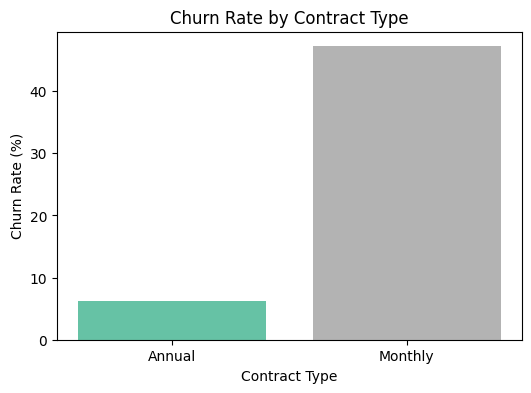

In [63]:
# 4.4 Churn Rate by Contract Type (Visualization)
churn_contract_viz = df.groupby('contract_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_contract_viz)))
plt.figure(figsize=(6,4))
plt.bar(churn_contract_viz.index, churn_contract_viz.values*100, color=colors)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.show()

In [64]:
df_visual = df.copy()

In [65]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

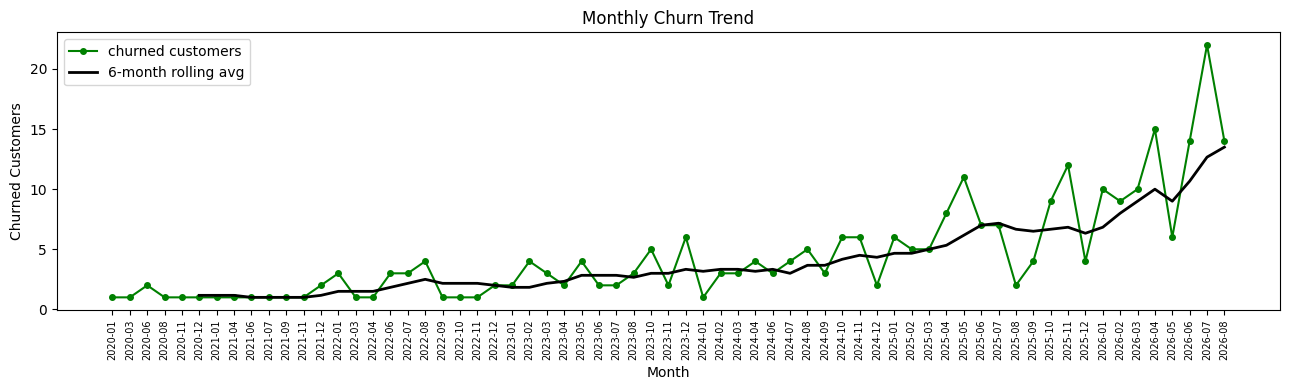

In [66]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(13,4))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green',
         marker='o', linewidth=1.5, markersize=4, label='churned customers')
plt.plot(churn_trend.index.astype(str), churn_trend.rolling(6).mean().values,
         color='black', linewidth=2, label='6-month rolling avg')

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.xticks(rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.show()


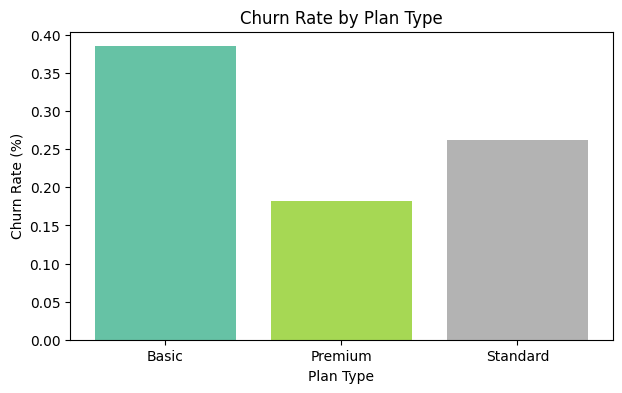

In [67]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

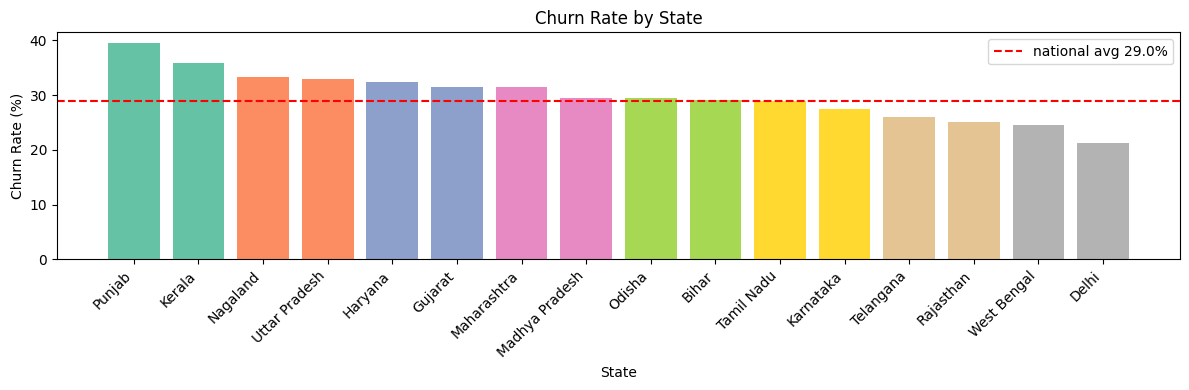

In [68]:
# 4.3 Churn Rate by State (sorted, 16 states, n=1,000 customers)
churn_state = df_visual.groupby('state')['churn_flag'].mean().mul(100).sort_values(ascending=False)

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_state)))

plt.figure(figsize=(12,4))
plt.bar(churn_state.index, churn_state.values, color=colors)
plt.axhline(df_visual['churn_flag'].mean()*100, color='red', linestyle='--',
            label=f"national avg {df_visual['churn_flag'].mean()*100:.1f}%")
plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


In [69]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [70]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Basic,Monthly,85,1,high,1
1,Premium,Annual,39,0,low,0
2,Basic,Annual,23,0,low,0
3,Premium,Monthly,49,0,low,0
4,Premium,Monthly,48,1,low,0


In [71]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [72]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

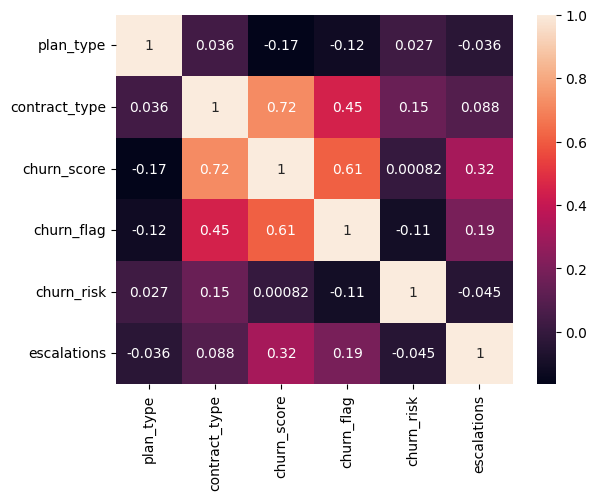

In [73]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [74]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : <StringArray>
['Basic', 'Premium', 'Standard']
Length: 3, dtype: str
contract_type : <StringArray>
['Monthly', 'Annual']
Length: 2, dtype: str
churn_risk : <StringArray>
['high', 'low', 'med']
Length: 3, dtype: str


In [75]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [76]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Basic,Monthly,85,1,high,1
1,Premium,Annual,39,0,low,0
2,Basic,Annual,23,0,low,0
3,Premium,Monthly,49,0,low,0
4,Premium,Monthly,48,1,low,0


In [77]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,0,0,85,1,2,1
1,2,1,39,0,0,0
2,0,1,23,0,0,0
3,2,0,49,0,0,0
4,2,0,48,1,0,0


<Axes: >

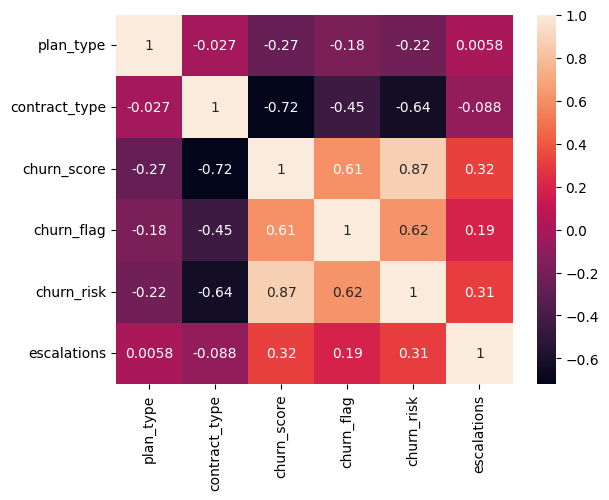

In [78]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

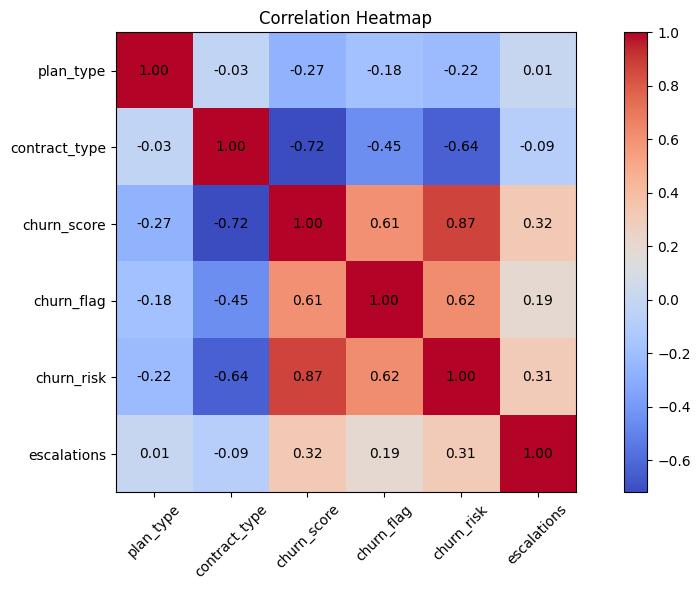

In [79]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

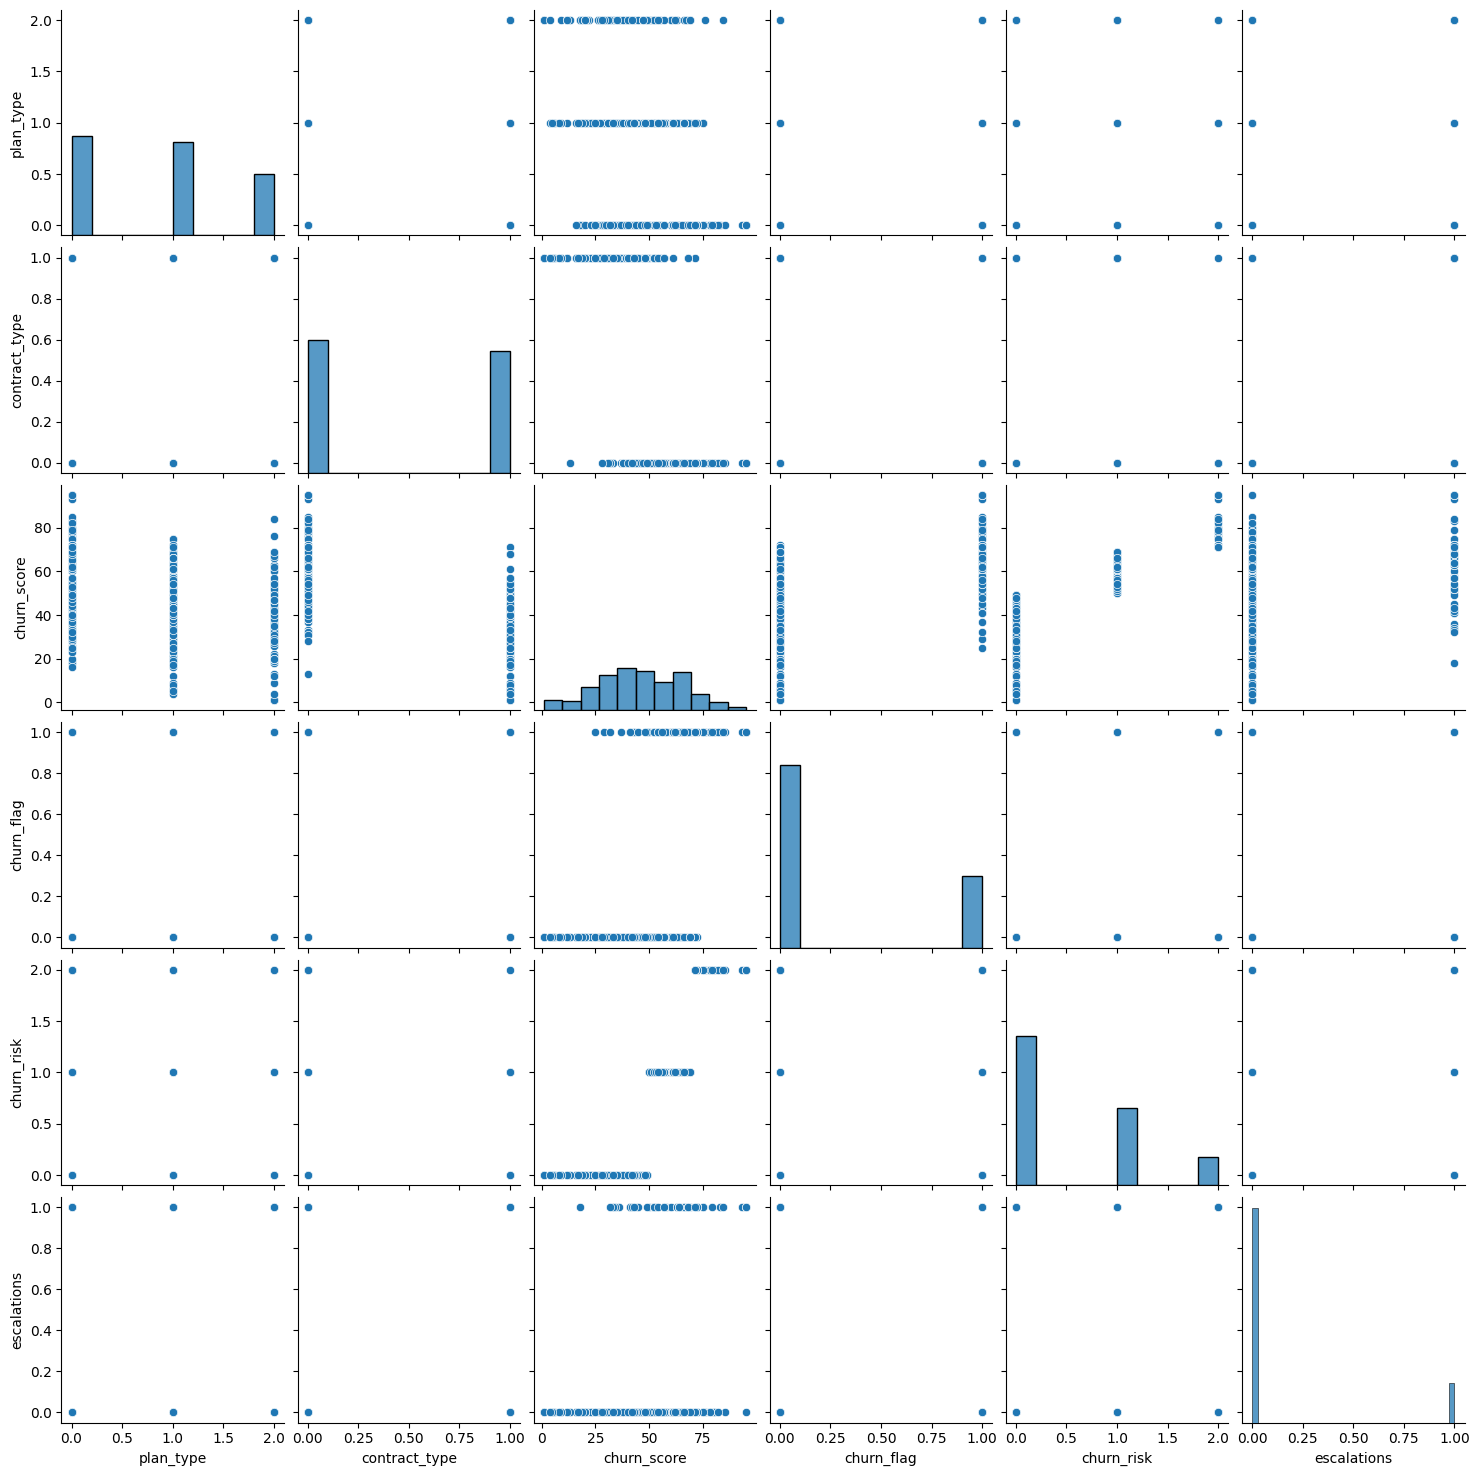

In [80]:
# pairplot - Plot pairwise relationships (sampled to 300 rows for readability)
sns.pairplot(df_encoded.sample(300, random_state=1), diag_kind='hist')
plt.show()


In [81]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

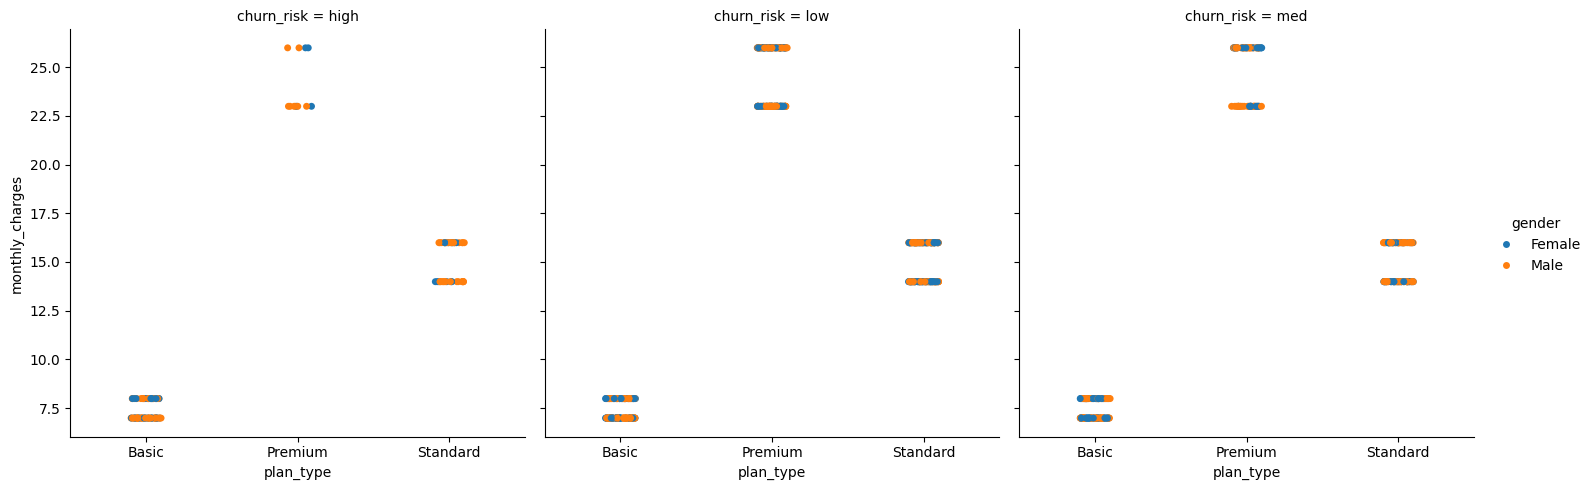

In [82]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [83]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.385013
Premium,0.182186
Standard,0.262295


In [84]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.385013,387,2890.13
Premium,0.182186,247,6032.53
Standard,0.262295,366,5468.34


---
## 5. Segment-Level Churn Intelligence (1,000-customer dataset)

With 1,000 customers the segment cells are large enough to compare, so this
section moves from single headline KPIs to the segment matrix, the driver
analysis and the revenue impact that a retention team would actually act on.


In [85]:
# 5.0 Per-customer support aggregation done in SQL (all tickets, not just the last one)
# The dedup step above keeps only each customer's most recent ticket, which understates
# escalations. Aggregating in SQL over the full ticket table fixes that.

conn = sqlite3.connect('customer_churn.db')

support_agg = pd.read_sql('''
    SELECT customerid,
           COUNT(*)                                        AS complaints_total,
           MAX(CASE WHEN escalations = 'Y' THEN 1 ELSE 0 END) AS escalated_any,
           ROUND(AVG(csat_score), 1)                       AS avg_csat
    FROM db_support
    GROUP BY customerid
''', conn)

conn.close()

df = df.merge(support_agg, on='customerid', how='left')
df['complaints_total'] = df['complaints_total'].fillna(0).astype(int)
df['escalated_any']    = df['escalated_any'].fillna(0).astype(int)

print('Customers in analytical table :', df['customerid'].nunique())
print('Customers with >=1 complaint  :', (df['complaints_total'] > 0).sum())
print('Customers with an escalation  :', df['escalated_any'].sum())
support_agg.head()

Customers in analytical table : 1000
Customers with >=1 complaint  : 526
Customers with an escalation  : 206


,customerid,complaints_total,escalated_any,avg_csat
0,0001-LNIVG,1,1,10.0
1,0031-ETJDH,1,0,70.0
2,0048-DHBNU,1,0,50.0
3,0064-FROIM,1,0,80.0
4,0065-OTOJV,1,0,100.0


In [86]:
# 5.1 Segment matrix - churn rate by Contract Type x Plan Type
segment_matrix = pd.pivot_table(
    df,
    index='contract_type',
    columns='plan_type',
    values='churn_flag',
    aggfunc='mean'
).mul(100).round(1)[['Basic', 'Standard', 'Premium']]

segment_counts = pd.pivot_table(
    df, index='contract_type', columns='plan_type', values='customerid', aggfunc='count'
)[['Basic', 'Standard', 'Premium']]

print('Churn rate (%) by contract x plan:')
print(segment_matrix)
print('\nCustomers per cell:')
print(segment_counts)

worst = segment_matrix.stack().idxmax()
print(f'\nWorst segment: {worst[0]} contract + {worst[1]} plan '
      f'-> {segment_matrix.stack().max()}% churn')

Churn rate (%) by contract x plan:
plan_type      Basic  Standard  Premium
contract_type                          
Annual          10.5       3.2      3.7
Monthly         63.1      43.3     29.5

Customers per cell:
plan_type      Basic  Standard  Premium
contract_type                          
Annual           181       156      108
Monthly          206       210      139

Worst segment: Monthly contract + Basic plan -> 63.1% churn


In [87]:
# 5.2 Churn driver table - churn rate and lift vs the base rate for every categorical driver
base = df['churn_flag'].mean()

rows = []
for col in ['contract_type', 'plan_type', 'subscription_type', 'gender', 'churn_risk']:
    g = df.groupby(col)['churn_flag'].agg(['count', 'mean'])
    for level, r in g.iterrows():
        rows.append({
            'driver': col,
            'segment': level,
            'customers': int(r['count']),
            'churn_rate_pct': round(r['mean'] * 100, 1),
            'lift_vs_base': round(r['mean'] / base, 2)
        })

driver_table = pd.DataFrame(rows).sort_values('churn_rate_pct', ascending=False)
print(f'Base churn rate = {base*100:.1f}%\n')
driver_table

Base churn rate = 29.0%



,driver,segment,customers,churn_rate_pct,lift_vs_base
10,churn_risk,high,134,86.6,2.99
1,contract_type,Monthly,555,47.2,1.63
12,churn_risk,med,343,42.3,1.46
2,plan_type,Basic,387,38.5,1.33
6,subscription_type,Paid,407,35.4,1.22
9,gender,Male,579,31.4,1.08
5,subscription_type,Organic,396,26.5,0.91
4,plan_type,Standard,366,26.2,0.90
8,gender,Female,421,25.7,0.88
7,subscription_type,Refferal,197,20.8,0.72


In [88]:
# 5.3 Support experience vs churn - does complaint volume predict leaving?
complaint_effect = (df.groupby('complaints_total')
                      .agg(customers=('customerid', 'count'),
                           churn_rate_pct=('churn_flag', lambda s: round(s.mean()*100, 1)))
                      .reset_index())
print('Churn rate by number of support tickets filed:')
print(complaint_effect)

esc = df.groupby('escalated_any')['churn_flag'].agg(['count', 'mean'])
print('\nChurn rate by escalation:')
print((esc['mean']*100).round(1).rename('churn_rate_pct'))

print('\nPoint-biserial corr(escalated_any, churn_flag) =',
      round(df['escalated_any'].corr(df['churn_flag']), 3))
print('Point-biserial corr(complaints_total, churn_flag) =',
      round(df['complaints_total'].corr(df['churn_flag']), 3))
print('Point-biserial corr(churn_score, churn_flag)     =',
      round(df['churn_score'].corr(df['churn_flag']), 3))

Churn rate by number of support tickets filed:
   complaints_total  customers  churn_rate_pct
0                 0        474            16.0
1                 1        364            35.4
2                 2        119            47.1
3                 3         32            68.8
4                 4         11            63.6

Churn rate by escalation:
escalated_any
0    22.8
1    52.9
Name: churn_rate_pct, dtype: float64

Point-biserial corr(escalated_any, churn_flag) = 0.268
Point-biserial corr(complaints_total, churn_flag) = 0.304
Point-biserial corr(churn_score, churn_flag)     = 0.609


In [89]:
# 5.4 Does the vendor churn_score actually rank risk? Decile lift table.
df['score_decile'] = pd.qcut(df['churn_score'], 10, labels=False, duplicates='drop') + 1

decile = (df.groupby('score_decile')
            .agg(customers=('customerid', 'count'),
                 avg_score=('churn_score', 'mean'),
                 churn_rate_pct=('churn_flag', lambda s: round(s.mean()*100, 1)))
            .reset_index())
decile['lift_vs_base'] = (decile['churn_rate_pct'] / (base*100)).round(2)
print(decile)

top3 = df[df['score_decile'] >= 8]
print(f"\nTop 3 risk deciles = {len(top3)} customers "
      f"({len(top3)/len(df)*100:.0f}% of base) and contain "
      f"{top3['churn_flag'].sum()/df['churn_flag'].sum()*100:.1f}% of all churned customers.")

   score_decile  customers  avg_score  churn_rate_pct  lift_vs_base
0             1        109  13.642202             0.0          0.00
1             2         97  25.505155             4.1          0.14
2             3         98  32.938776             4.1          0.14
3             4        111  39.882883             4.5          0.16
4             5         89  45.584270            15.7          0.54
5             6        109  51.623853            19.3          0.67
6             7         92  56.673913            40.2          1.39
7             8        100  62.210000            48.0          1.66
8             9        102  68.901961            67.6          2.33
9            10         93  80.150538            94.6          3.26

Top 3 risk deciles = 295 customers (30% of base) and contain 70.7% of all churned customers.


In [90]:
# 5.5 Revenue impact - monthly recurring revenue lost, and where it is concentrated
mrr_total   = df['monthly_charges'].sum()
mrr_lost    = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
arr_lost    = mrr_lost * 12
cltv_lost   = df.loc[df['churn_flag'] == 1, 'cltv'].sum()

print(f'Total book MRR                 : Rs {mrr_total:,.2f}')
print(f'MRR lost to churn              : Rs {mrr_lost:,.2f} ({mrr_lost/mrr_total*100:.1f}% of book)')
print(f'Annualised revenue at risk     : Rs {arr_lost:,.2f}')
print(f'CLTV tied up in churned users  : Rs {cltv_lost:,.0f}')

rev_by_segment = (df[df['churn_flag'] == 1]
                    .groupby(['contract_type', 'plan_type'])['monthly_charges']
                    .sum().sort_values(ascending=False).round(2))
print('\nLost MRR by segment:')
print(rev_by_segment)
print(f'\nShare of lost MRR from Monthly contracts: '
      f"{df.loc[(df.churn_flag==1) & (df.contract_type=='Monthly'), 'monthly_charges'].sum()/mrr_lost*100:.1f}%")

Total book MRR                 : Rs 14,391.00
MRR lost to churn              : Rs 3,688.10 (25.6% of book)
Annualised revenue at risk     : Rs 44,257.20
CLTV tied up in churned users  : Rs 84,022

Lost MRR by segment:
contract_type  plan_type
Monthly        Standard     1377.09
               Premium      1017.59
               Basic         972.70
Annual         Basic         142.81
               Premium        97.96
               Standard       79.95
Name: monthly_charges, dtype: float64

Share of lost MRR from Monthly contracts: 91.3%


In [91]:
# 5.6 Why they leave - cancellation reason mix (churned customers only)
reason_mix = (df[df['churn_flag'] == 1]['cancellation_reason']
                .value_counts()
                .to_frame('customers')
                .assign(pct_of_churn=lambda d: (d['customers']/d['customers'].sum()*100).round(1)))
print(reason_mix)

reason_rev = (df[df['churn_flag'] == 1]
                .groupby('cancellation_reason')['monthly_charges'].sum()
                .sort_values(ascending=False).round(2))
print('\nLost MRR by cancellation reason:')
print(reason_rev)

                        customers  pct_of_churn
cancellation_reason                            
No longer needed               46          15.9
Too expensive                  44          15.2
Technical problems             43          14.8
Billing issue                  43          14.8
Moved to family plan           41          14.1
Switched to competitor         38          13.1
Poor service quality           35          12.1

Lost MRR by cancellation reason:
cancellation_reason
Too expensive             596.56
No longer needed          583.54
Switched to competitor    528.62
Moved to family plan      520.59
Technical problems        511.57
Billing issue             504.57
Poor service quality      442.65
Name: monthly_charges, dtype: float64


In [92]:
# 5.7 Tenure analysis - when in the lifecycle do customers leave?
churned = df[df['churn_flag'] == 1]
retained = df[df['churn_flag'] == 0]

print(f'Avg tenure, churned customers  : {churned["tenure_days"].mean():.0f} days '
      f'({churned["tenure_days"].mean()/30.44:.1f} months)')
print(f'Avg tenure, retained customers : {retained["tenure_days"].mean():.0f} days '
      f'({retained["tenure_days"].mean()/30.44:.1f} months)')
print(f'Median tenure at cancellation  : {churned["tenure_days"].median():.0f} days')

bins   = [0, 90, 180, 365, 730, 10000]
labels = ['0-3 mo', '3-6 mo', '6-12 mo', '1-2 yr', '2 yr+']
churned_buckets = pd.cut(churned['tenure_days'], bins=bins, labels=labels)
dist = (churned_buckets.value_counts(normalize=True).reindex(labels)*100).round(1)
print('\nWhen churn happens (% of all churned customers):')
print(dist)
print(f'\nChurn inside the first 12 months = {dist.iloc[:3].sum():.1f}% of all churn')

Avg tenure, churned customers  : 678 days (22.3 months)
Avg tenure, retained customers : 1273 days (41.8 months)
Median tenure at cancellation  : 476 days

When churn happens (% of all churned customers):
tenure_days
0-3 mo      9.7
3-6 mo     14.1
6-12 mo    15.2
1-2 yr     25.2
2 yr+      35.9
Name: proportion, dtype: float64

Churn inside the first 12 months = 39.0% of all churn


In [93]:
# 5.8 Geography - churn by state (only states with a meaningful sample)
state_tbl = (df.groupby('state')
               .agg(customers=('customerid', 'count'),
                    churn_rate_pct=('churn_flag', lambda s: round(s.mean()*100, 1)),
                    lost_mrr=('monthly_charges', lambda s: 0))
               .reset_index())

state_tbl['lost_mrr'] = (df[df['churn_flag'] == 1].groupby('state')['monthly_charges']
                           .sum().round(2).reindex(state_tbl['state']).fillna(0).values)

state_tbl = state_tbl[state_tbl['customers'] >= 30].sort_values('churn_rate_pct', ascending=False)
print(f'States with n >= 30 customers ({len(state_tbl)} of {df["state"].nunique()}):')
print(state_tbl.to_string(index=False))

States with n >= 30 customers (13 of 16):
         state  customers  churn_rate_pct  lost_mrr
        Punjab         38            39.5    223.85
        Kerala         53            35.8    244.81
 Uttar Pradesh         88            33.0    411.71
       Haryana         34            32.4    135.89
       Gujarat         70            31.4    314.78
   Maharashtra        137            31.4    508.57
Madhya Pradesh         34            29.4    114.90
    Tamil Nadu         90            28.9    303.74
     Karnataka        106            27.4    379.71
     Telangana         77            26.0    286.80
     Rajasthan         44            25.0    107.89
   West Bengal         61            24.6    170.85
         Delhi        118            21.2    326.75


In [94]:
# 5.9 Satisfaction - CSAT vs churn (customers who filed at least one ticket)
csat_view = df[df['complaints_total'] > 0]

print('Avg CSAT by churn status (complainers only):')
print(csat_view.groupby('churn_flag')['avg_csat'].agg(['count', 'mean']).round(2))

print('\nAvg CSAT by escalation:')
print(csat_view.groupby('escalated_any')['avg_csat'].agg(['count', 'mean']).round(2))

print('\ncorr(avg_csat, churn_flag) among complainers =',
      round(csat_view['avg_csat'].corr(csat_view['churn_flag']), 3))

Avg CSAT by churn status (complainers only):
            count   mean
churn_flag              
0             312  69.30
1             214  37.52

Avg CSAT by escalation:
               count   mean
escalated_any              
0                320  65.87
1                206  41.60

corr(avg_csat, churn_flag) among complainers = -0.683


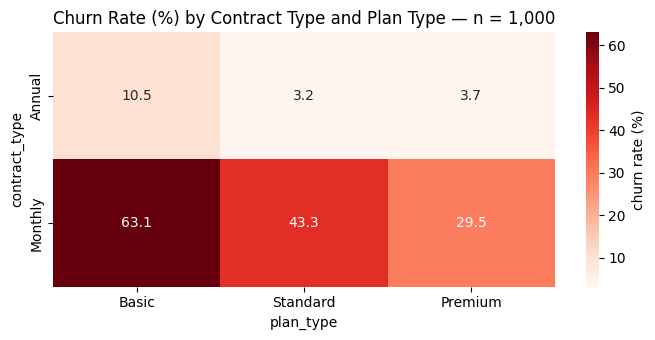

In [95]:
# 5.10 Visualisation - the segment matrix as a heatmap
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(segment_matrix, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'churn rate (%)'}, ax=ax)
ax.set_title('Churn Rate (%) by Contract Type and Plan Type — n = 1,000')
plt.tight_layout()
plt.show()

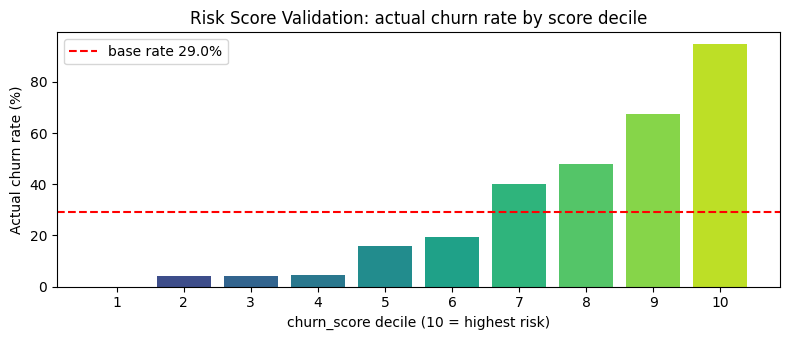

In [96]:
# 5.11 Visualisation - churn score decile lift
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(decile['score_decile'], decile['churn_rate_pct'], color=plt.cm.viridis(np.linspace(0.15, 0.9, len(decile))))
ax.axhline(base*100, color='red', linestyle='--', label=f'base rate {base*100:.1f}%')
ax.set_xlabel('churn_score decile (10 = highest risk)')
ax.set_ylabel('Actual churn rate (%)')
ax.set_title('Risk Score Validation: actual churn rate by score decile')
ax.set_xticks(decile['score_decile'])
ax.legend()
plt.tight_layout()
plt.show()

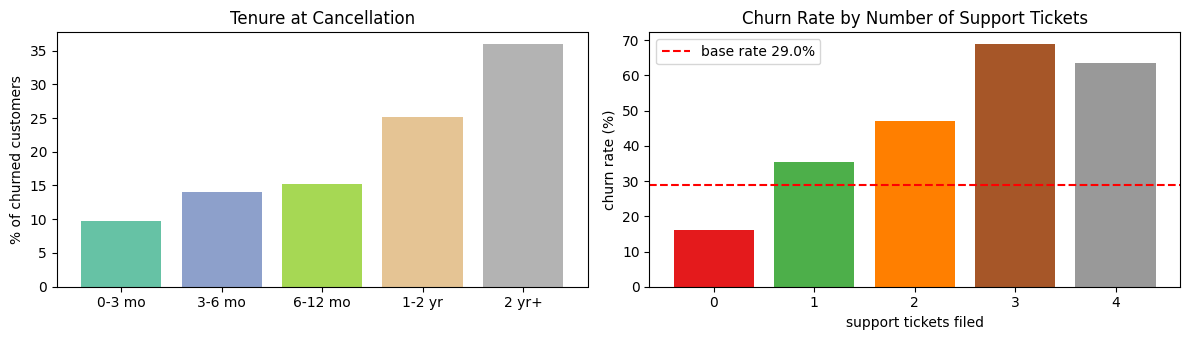

In [97]:
# 5.12 Visualisation - when customers leave, and support-ticket effect
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].bar(dist.index.astype(str), dist.values, color=plt.cm.Set2(np.linspace(0, 1, len(dist))))
axes[0].set_title('Tenure at Cancellation')
axes[0].set_ylabel('% of churned customers')

axes[1].bar(complaint_effect['complaints_total'].astype(str), complaint_effect['churn_rate_pct'],
            color=plt.cm.Set1(np.linspace(0, 1, len(complaint_effect))))
axes[1].axhline(base*100, color='red', linestyle='--', label=f'base rate {base*100:.1f}%')
axes[1].set_title('Churn Rate by Number of Support Tickets')
axes[1].set_xlabel('support tickets filed')
axes[1].set_ylabel('churn rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.13 Final KPI summary

Everything the resume / stakeholder summary quotes is computed here in one place,
so every number is traceable back to a single cell.


In [98]:
# 5.13 Consolidated KPI summary
monthly_churn = df.loc[df.contract_type == 'Monthly', 'churn_flag'].mean()*100
annual_churn  = df.loc[df.contract_type == 'Annual',  'churn_flag'].mean()*100

kpi_summary = {
    'Customers analysed'                : df['customerid'].nunique(),
    'Support tickets processed'         : int(support_agg['complaints_total'].sum()),
    'Overall churn rate (%)'            : round(df['churn_flag'].mean()*100, 1),
    'Retention rate (%)'                : round(100 - df['churn_flag'].mean()*100, 1),
    'Monthly-contract churn (%)'        : round(monthly_churn, 1),
    'Annual-contract churn (%)'         : round(annual_churn, 1),
    'Monthly vs annual churn gap (x)'   : round(monthly_churn/annual_churn, 1),
    'Basic-plan churn (%)'              : round(df.loc[df.plan_type=='Basic','churn_flag'].mean()*100, 1),
    'Premium-plan churn (%)'            : round(df.loc[df.plan_type=='Premium','churn_flag'].mean()*100, 1),
    'ARPU (Rs)'                         : round(df['monthly_charges'].mean(), 2),
    'Avg tenure (days)'                 : round(df['tenure_days'].mean()),
    'Avg tenure at cancellation (days)' : round(churned['tenure_days'].mean()),
    'Churn within first 12 months (%)'  : round(dist.iloc[:3].sum(), 1),
    'MRR lost to churn (Rs)'            : round(mrr_lost, 2),
    'Annualised revenue at risk (Rs)'   : round(arr_lost, 2),
    'Share of lost MRR from Monthly (%)': round(df.loc[(df.churn_flag==1)&(df.contract_type=='Monthly'),'monthly_charges'].sum()/mrr_lost*100, 1),
    'Escalation rate (%)'               : round(df['escalated_any'].mean()*100, 1),
    'Churn if escalated (%)'            : round(df.loc[df.escalated_any==1,'churn_flag'].mean()*100, 1),
    'Churn if no escalation (%)'        : round(df.loc[df.escalated_any==0,'churn_flag'].mean()*100, 1),
    'Avg complaints per user'           : round(df['complaints_total'].mean(), 2),
    'corr(escalation, churn)'           : round(df['escalated_any'].corr(df['churn_flag']), 3),
    'corr(churn_score, churn)'          : round(df['churn_score'].corr(df['churn_flag']), 3),
    'High-risk segment share (%)'       : round((df['churn_risk']=='high').mean()*100, 1),
    'Churn captured in top 3 deciles(%)': round(top3['churn_flag'].sum()/df['churn_flag'].sum()*100, 1),
}

kpi_df = pd.DataFrame(kpi_summary.items(), columns=['KPI', 'Value'])
pd.set_option('display.max_rows', None)
print(kpi_df.to_string(index=False))

                               KPI     Value
                Customers analysed  1000.000
         Support tickets processed   742.000
            Overall churn rate (%)    29.000
                Retention rate (%)    71.000
        Monthly-contract churn (%)    47.200
         Annual-contract churn (%)     6.300
   Monthly vs annual churn gap (x)     7.500
              Basic-plan churn (%)    38.500
            Premium-plan churn (%)    18.200
                         ARPU (Rs)    14.390
                 Avg tenure (days)  1100.000
 Avg tenure at cancellation (days)   678.000
  Churn within first 12 months (%)    39.000
            MRR lost to churn (Rs)  3688.100
   Annualised revenue at risk (Rs) 44257.200
Share of lost MRR from Monthly (%)    91.300
               Escalation rate (%)    20.600
            Churn if escalated (%)    52.900
        Churn if no escalation (%)    22.800
           Avg complaints per user     0.740
           corr(escalation, churn)     0.268
          

In [99]:
# Export the final analytical dataset (1,000 customers, all engineered features)
df.to_csv('exported_churn_data.csv', index=False)
kpi_df.to_csv('kpi_summary.csv', index=False)
print('exported_churn_data.csv :', df.shape)
print('kpi_summary.csv         :', kpi_df.shape)
print('\nColumns:', list(df.columns))

exported_churn_data.csv : (1000, 27)
kpi_summary.csv         : (24, 2)

Columns: ['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'tenure_days', 'churn_risk', 'complaints_total', 'escalated_any', 'avg_csat', 'score_decile']
